In [9]:
import numpy as np
import jax
import jax.numpy as jnp

from scattering_simulation import prepare_lens_scattering_solver
import topology_parametrization
import field_postprocessing
from manufacturing_constraints import too_thin_area

from field_plotter import visible_amplitude_colormap
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
period = 2000
p_red = period / 650
p_green = period / 550
p_blue = period / 450

focal_distance = 3500

In [3]:
n_px = 100
topology = topology_parametrization.GaussianField(n_px, sigma=16, symmetry_type='main_diagonal')
min_width = 100
min_width_px = round(min_width * n_px / period)
min_width_px = (min_width_px // 2) * 2 + 1
print('Min width in pixels:', min_width_px, 'which corresponds to', min_width_px * period / n_px, 'nm')

Min width in pixels: 5 which corresponds to 100.0 nm


In [4]:
common_sim_kwargs = {'period': 2000, 'lens_thickness': 600, 'substrate_thickness': 500,
                     'approximate_number_of_terms': 600, 'propagate_by_distance': 0}
red_sim, red_basis = prepare_lens_scattering_solver(wavelength=650, **common_sim_kwargs)
green_sim, green_basis = prepare_lens_scattering_solver(wavelength=550, **common_sim_kwargs)
blue_sim, blue_basis = prepare_lens_scattering_solver(wavelength=450, **common_sim_kwargs)

print(red_basis.shape, green_basis.shape, blue_basis.shape)

(2, 29) (2, 45) (2, 61)


In [40]:
def params_to_normalized_amps_xy_rgb(params, sim_func_red, sim_func_green, sim_func_blue):
    amps_red = sim_func_red(params).squeeze()[:red_basis.shape[1]].T
    amps_green = sim_func_green(params).squeeze()[:green_basis.shape[1]].T
    amps_blue = sim_func_blue(params).squeeze()[:blue_basis.shape[1]].T

    amps_red = field_postprocessing.normalize_power(amps_red, p_red, red_basis)[:2]
    amps_green = field_postprocessing.normalize_power(amps_green, p_green, green_basis)[:2]
    amps_blue = field_postprocessing.normalize_power(amps_blue, p_blue, blue_basis)[:2]

    amps_red = field_postprocessing.propagate_amps_in_free_space(amps_red, focal_distance, red_basis, 650, period)
    amps_green = field_postprocessing.propagate_amps_in_free_space(amps_green, focal_distance, green_basis, 550, period)
    amps_blue = field_postprocessing.propagate_amps_in_free_space(amps_blue, focal_distance, blue_basis, 450, period)

    return amps_red, amps_green, amps_blue

def params_to_focused_powers(params):
    sim_funcs = (lambda x: red_sim(topology(x)), lambda x: green_sim(topology(x)), lambda x: blue_sim(topology(x)))

    amps_red, amps_green, amps_blue = params_to_normalized_amps_xy_rgb(params, *sim_funcs)

    red_power = field_postprocessing.calculate_focused_power(amps_red, p_red, red_basis, relative_focal_point=(0.25, 0.25))
    green_power = (
        field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.25, 0.75))
        + field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.75, 0.25))
    )
    blue_power = field_postprocessing.calculate_focused_power(amps_blue, p_blue, blue_basis, relative_focal_point=(0.75, 0.75))

    return jnp.array([red_power, green_power, blue_power])

In [5]:
x = np.load('lens_designs/freeform_seed112.npy')
pattern = topology(x)
pattern_high_res = topology(x, 1000)

In [11]:
I = np.array(pattern)
I8 = (((I - I.min()) / (I.max() - I.min())) * 255.9).astype(np.uint8)
img = Image.fromarray(I8)
img.save("final_pattern_i8.png")

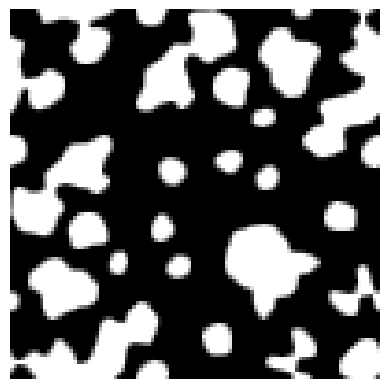

In [8]:
# fully_binarized_pattern = (pattern_high_res > 0.5).astype(float)
# plt.imshow(np.tile(fully_binarized_pattern, (1, 2)), cmap='gray')
# plt.imshow(fully_binarized_pattern, cmap='gray')
plt.imshow(pattern, cmap='gray')
plt.axis('off')
plt.savefig('final_lens_pattern.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [42]:
params_to_focused_powers(x)

Array([0.6633802, 0.669225 , 0.6643794], dtype=float32)

In [43]:
fully_binarized_pattern = (pattern_high_res > 0.5).astype(float)

sim_funcs = (red_sim, green_sim, blue_sim)
amps_red, amps_green, amps_blue = params_to_normalized_amps_xy_rgb(fully_binarized_pattern, *sim_funcs)

red_power = field_postprocessing.calculate_focused_power(amps_red, p_red, red_basis, relative_focal_point=(0.25, 0.25))
green_power = (
    field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.25, 0.75))
    + field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.75, 0.25))
)
blue_power = field_postprocessing.calculate_focused_power(amps_blue, p_blue, blue_basis, relative_focal_point=(0.75, 0.75))

print(red_power, green_power, blue_power)

0.6559112 0.667699 0.66367215


41


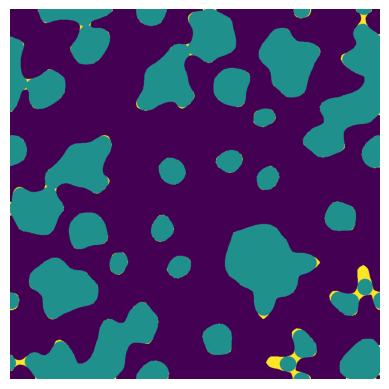

In [50]:
import manufacturing_constraints

fully_binarized_pattern = (pattern_high_res > 0.5).astype(float)

min_width_px_high_res = round(80 * fully_binarized_pattern.shape[0] / period)
min_width_px_high_res = (min_width_px_high_res // 2) * 2 + 1
print(min_width_px_high_res)

too_thin_solid = manufacturing_constraints.detect_too_thin_solid(fully_binarized_pattern, min_width_px_high_res)
too_thin_void = manufacturing_constraints.detect_too_thin_void(fully_binarized_pattern, min_width_px_high_res)
plt.imshow(too_thin_solid + fully_binarized_pattern)
# plt.imshow(2 * too_thin_void + fully_binarized_pattern)
plt.axis('off')
plt.show()

In [ ]:
# TODO: переделать картинку, сейчас она слегка не периодическая. всё-таки руками построить периодическое гауссово поле и потом бинаризовать
#       потом дорисовать толщину где надо от руки и проверить какая будет фокусировка

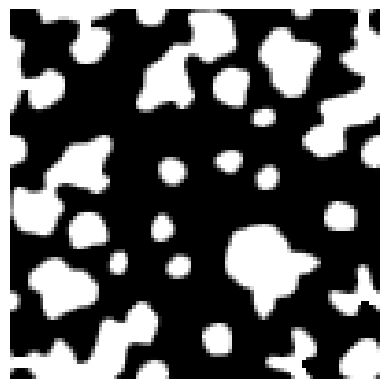

In [44]:
img_cleaned = Image.open('final_pattern_i8_cleaned_2.png')
pattern_cleaned = np.array(img_cleaned)[..., 0] / 255
diag_values = np.diag(pattern_cleaned).copy()
pattern_cleaned = pattern_cleaned * np.tri(100, k=-1)
pattern_cleaned += pattern_cleaned.T + np.diag(diag_values)

plt.imshow(pattern_cleaned, cmap='gray')
plt.axis('off')
plt.show()

In [45]:
def focused_powers_from_pattern(pattern):
    sim_funcs = (red_sim, green_sim, blue_sim)
    amps_red, amps_green, amps_blue = params_to_normalized_amps_xy_rgb(pattern, *sim_funcs)
    red_power = field_postprocessing.calculate_focused_power(amps_red, p_red, red_basis, relative_focal_point=(0.25, 0.25))
    green_power = (
        field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.25, 0.75))
        + field_postprocessing.calculate_focused_power(amps_green, p_green, green_basis, relative_focal_point=(0.75, 0.25))
    )
    blue_power = field_postprocessing.calculate_focused_power(amps_blue, p_blue, blue_basis, relative_focal_point=(0.75, 0.75))

    return np.array([red_power, green_power, blue_power])

In [46]:
print(focused_powers_from_pattern(pattern))
print(focused_powers_from_pattern(pattern_cleaned))

[0.6633802 0.669225  0.6643794]
[0.6493446  0.6661046  0.62664163]


In [48]:
I = np.tile(np.array(pattern_cleaned), (3, 3))
I8 = (((I - I.min()) / (I.max() - I.min())) * 255.9).astype(np.uint8)
img = Image.fromarray(I8)
img.save("final_pattern_cleaned_3x3_tiles.png")

5


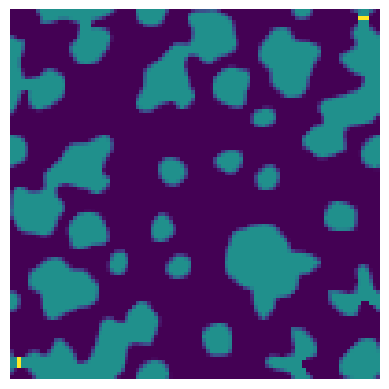

In [56]:
min_width_px_high_res = round(80 * pattern_cleaned.shape[0] / period)
min_width_px_high_res = (min_width_px_high_res // 2) * 2 + 1
print(min_width_px_high_res)

too_thin_solid = manufacturing_constraints.detect_too_thin_solid(pattern_cleaned, min_width_px_high_res)
too_thin_void = manufacturing_constraints.detect_too_thin_void(pattern_cleaned, min_width_px_high_res)
plt.imshow(too_thin_solid + pattern_cleaned)
# plt.imshow(2 * too_thin_void + pattern_cleaned)
plt.axis('off')
plt.show()

4.0


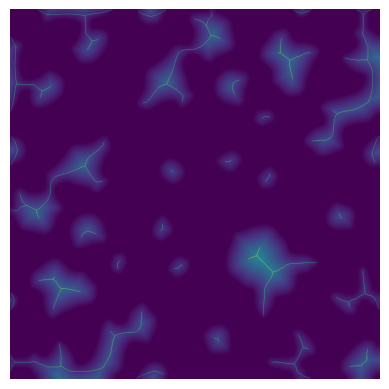

In [76]:
# find true minimum width
import cv2
from skimage.morphology import skeletonize

upscaled_binary = cv2.resize(pattern_cleaned, dsize=(1000, 1000), interpolation=cv2.INTER_CUBIC) > 0.5
upscaled_binary = upscaled_binary.astype(np.uint8) * 255
# for void
# upscaled_binary = 255 - upscaled_binary

distance_map = cv2.distanceTransform(upscaled_binary, cv2.DIST_L2, 5)
skeleton = skeletonize(upscaled_binary > 0)
distance_on_skeleton = skeleton * distance_map

actual_min_width = 2 * np.min(distance_map[np.where(skeleton)])
print(actual_min_width)

plt.imshow(distance_map + 100 * skeleton)
# plt.imshow(distance_on_skeleton)
# plt.colorbar()
plt.axis('off')
plt.show()